<>:208: SyntaxWarning: invalid escape sequence '\p'
<>:208: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_158/3555889774.py:208: SyntaxWarning: invalid escape sequence '\p'
  label=r'$\frac{-\pi\alpha}{J}(\epsilon_1^2+\epsilon_2^2-\epsilon_1\epsilon_2)$'


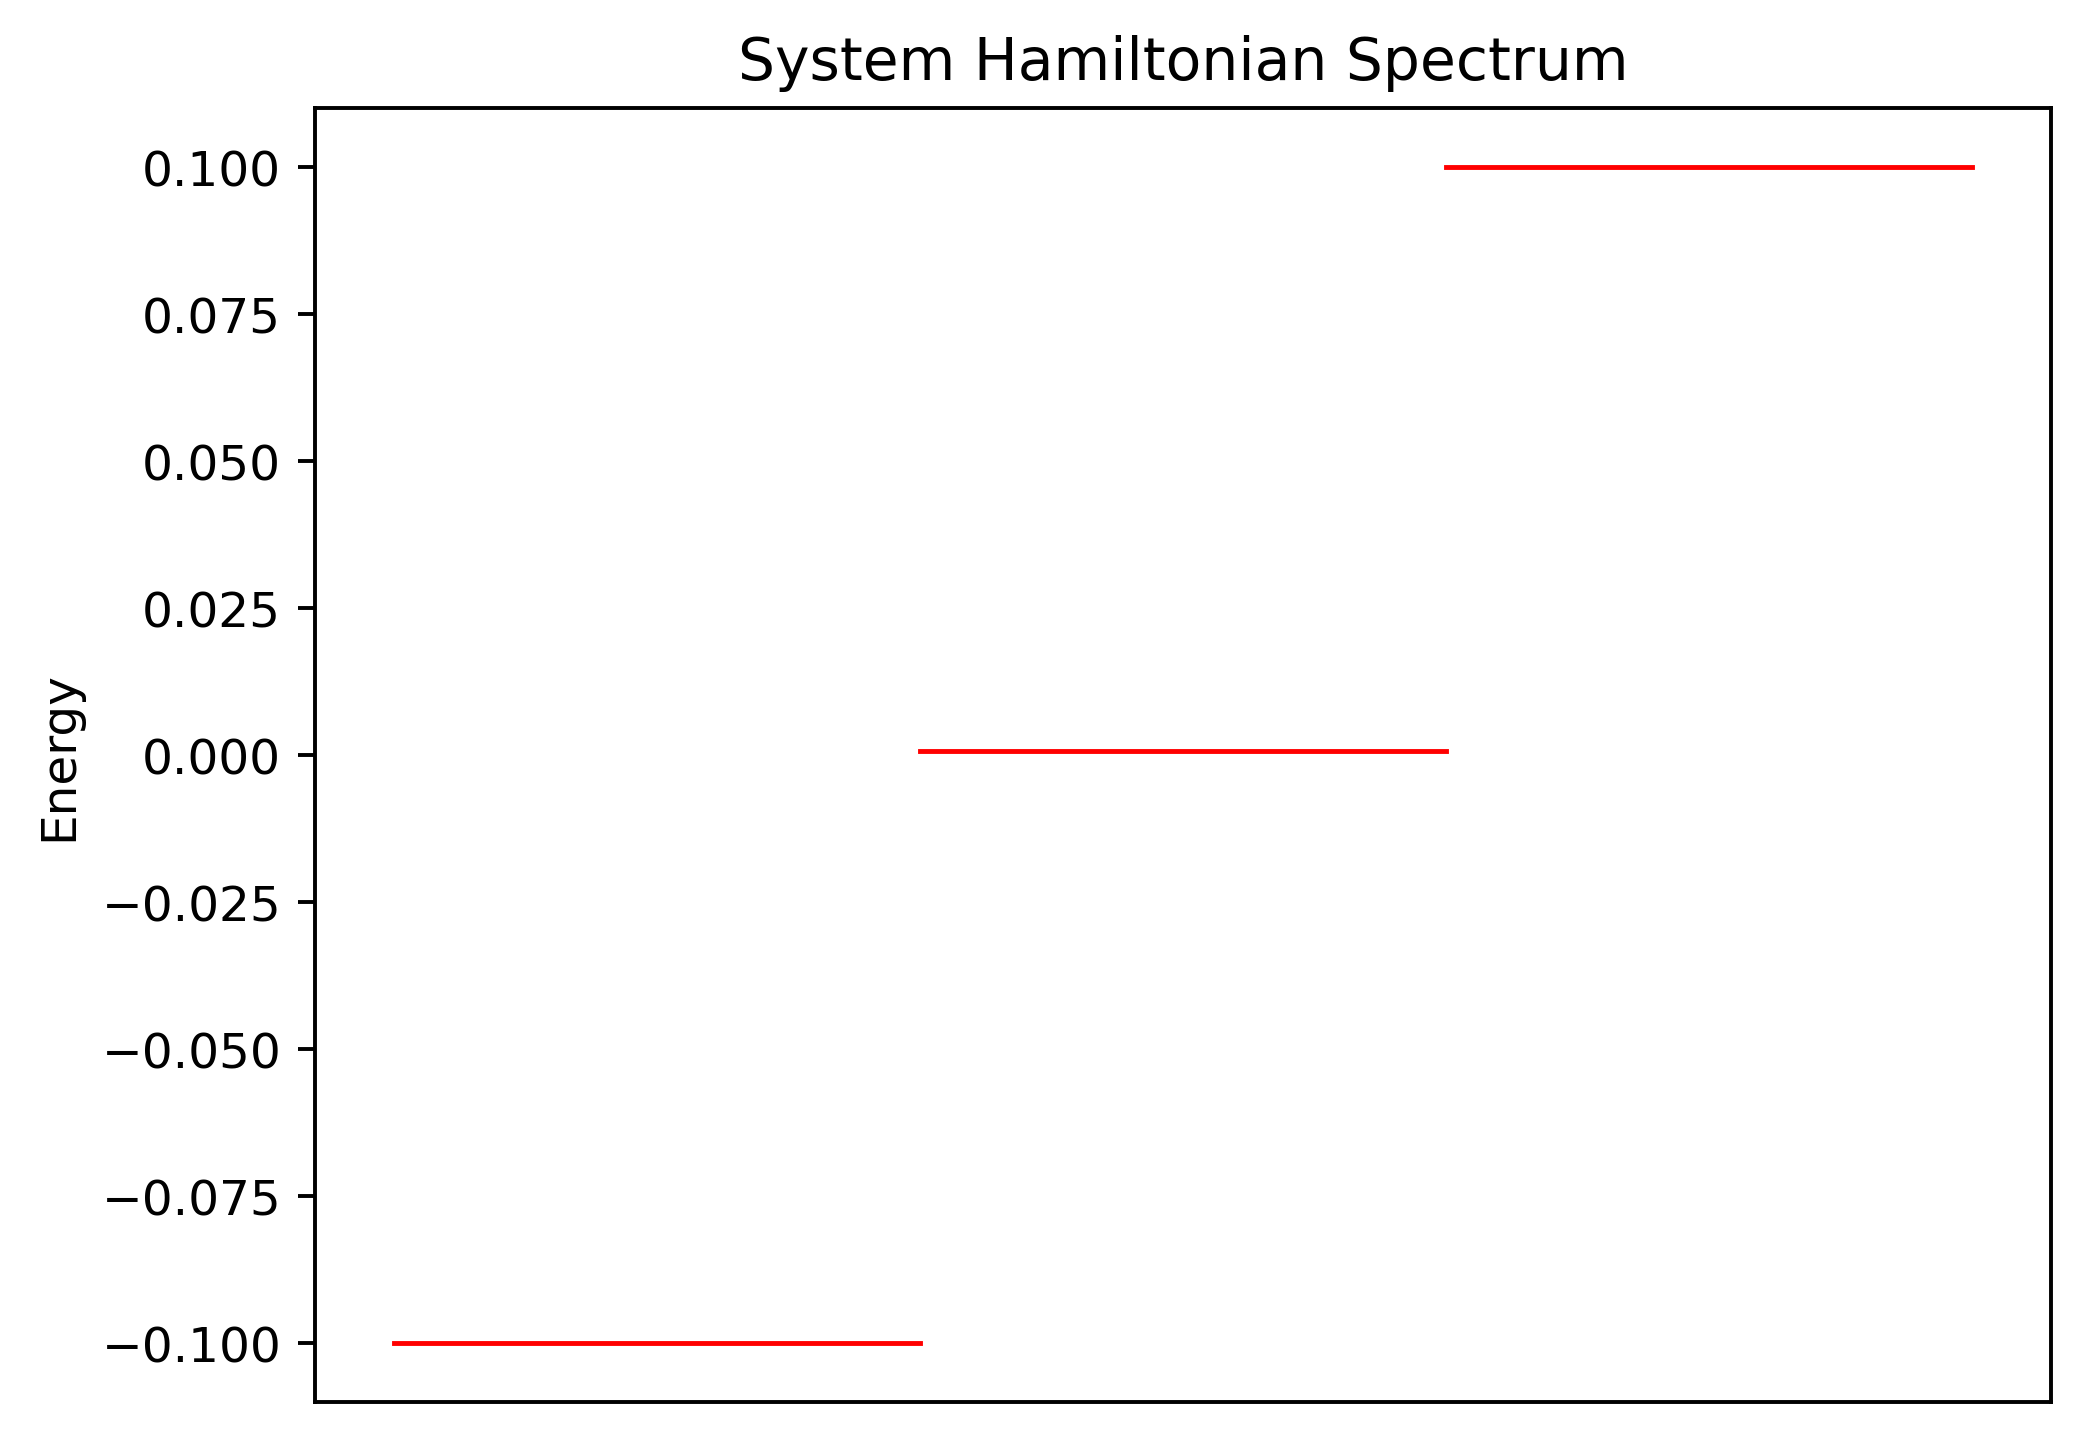

trace= 1.0
trace of altered= 1.0


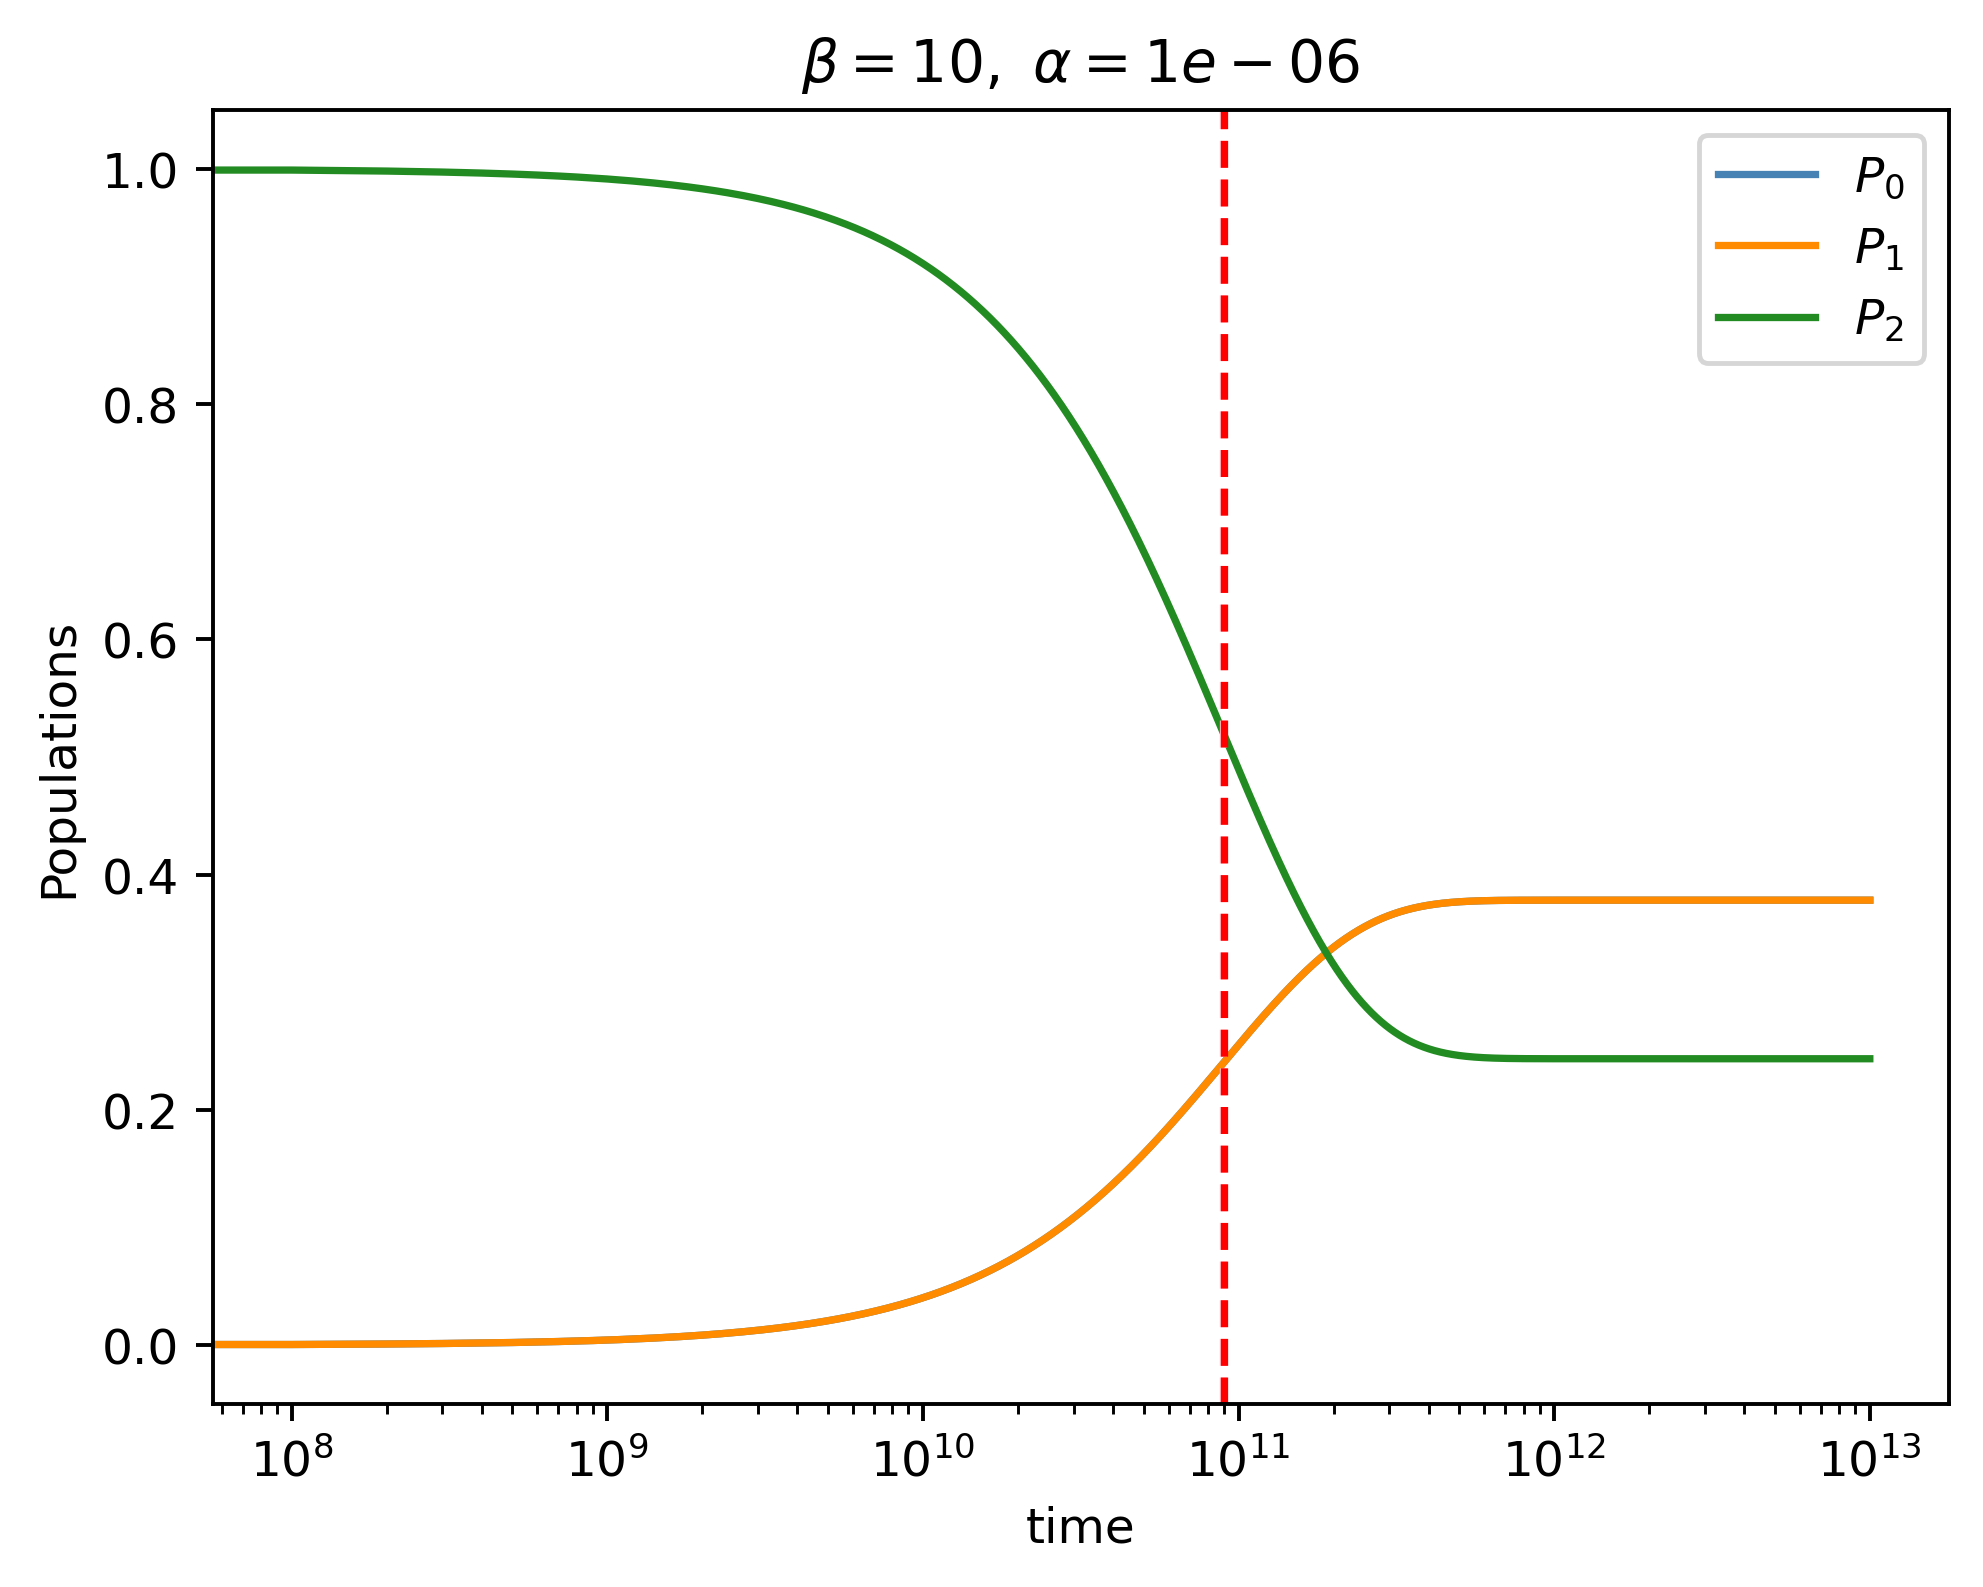

"\nT_array=np.linspace(0.001,100,100)\nT_arraysmall=np.linspace(0.001,.1,100)\nT_arraybig=np.linspace(10,100,100)\ngap_array = np.array([gap(T) for T in T_array])\ngap_arraysmall=np.array([gap(T) for T in T_arraysmall])\ngap_arraybig=np.array([gap(T) for T in T_arraybig])\ndef g(T):\n    B=1/T\n    return-((np.pi*Alpha)/(2*J))*(-eps*Eps+(eps**2+Eps**2)/np.tanh(J*B/2))*(2+1/np.cosh(J*B))\n\n\n\nfig, axs = plt.subplots(1, 3, figsize=(12, 4))\n\n# --- left ---\naxs[0].plot(T_array, gap_array, color='darkblue', label='Numeric')\naxs[0].plot(T_array, g(T_array), color='orange', ls='--', label='Approximation')\naxs[0].grid()\naxs[0].set_xscale('log')\naxs[0].legend()\n\n# --- middle ---\naxs[1].plot(\n    T_arraysmall,\n    -(np.pi * Alpha / J) * (eps**2 + Eps**2 - eps * Eps) * np.ones_like(T_arraysmall),\n    color='red',\n    alpha=0.5,\n    label=r'$\x0crac{-\\pi\x07lpha}{J}(\\epsilon_1^2+\\epsilon_2^2-\\epsilon_1\\epsilon_2)$'\n)\naxs[1].plot(T_arraysmall, gap_arraysmall, color='darkblue

In [2]:
%matplotlib inline
import numpy as np
from utils import _build_redfield_numba, build_redfield_tensor, evolve_density_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.rcParams['figure.dpi']=350

#coupling params
J = 0.1
eps = 1e-4 
Eps=np.sqrt(8)*eps
Alpha=1e-6
Beta=10
Omega_c=50
E=7*eps
#bath params- assuming 3 decoupled ohmic baths
alpha_list=np.array(Alpha*np.ones(3))
wc_list=np.array(Omega_c*np.ones(3))
beta_list=np.array(Beta*np.ones(3))

H=np.array([[0,J,Eps],
            [J,0,Eps],
            [Eps,Eps,E]
           ])
#plot spectrum


energies,evectors=np.linalg.eigh(H)
plt.figure()
for energy,k in zip(energies,range(len(energies))):
    x=1/2*np.linspace(k,k+1)
    plt.plot(x,energy*np.ones_like(x),color='r',lw=1)
plt.ylabel('Energy')
plt.title('System Hamiltonian Spectrum')
plt.xticks([])
plt.show()

    
#system-bath coupling operators 
S_list=[]
for i in range(H.shape[0]):
    S=np.zeros((H.shape[0],H.shape[0]))
    S[i,i]=1
    S_list.append(S)
def dens(alpha, wc, x): #J(w) spectral density function for baths
    return 2 * alpha * x * np.exp(-x / wc)

def eta(beta, x):  #the thermal factor
    return 1 / np.expm1(beta * x)  # better than exp(beta*x)-1 near x=0

def gamma_func(w): #Laplace transforms of bath correlation functions 
    gammas = []
    absw = abs(w)
    for alpha, wc, beta in zip(alpha_list, wc_list, beta_list):

        if absw < 1e-12:
            # Ohmic zero-frequency limit:
            # dens(alpha,wc,w) * eta(beta,w) -> 2 alpha / beta
            g = (np.pi/2)*(alpha/beta)
        elif w > 0:
            g = (np.pi/4)*dens(alpha,wc,absw)*(eta(beta,absw)+1) #ignoring the complex part with the Cauchy PV dist.
        else:
            g = (np.pi/4)*dens(alpha,wc,absw)*eta(beta,absw)
        gammas.append(g + 0j) #ensures dtype is complex with 0 complex part
   
    return np.array(gammas, dtype=np.complex128)

R,U=build_redfield_tensor(H,S_list,gamma_func, False,1e-10,True) 

COB=np.array([
    [1,0,0,0,0,0,0,0,0],
    [0,0,0,0,1,0,0,0,0],
    [0,0,0,0,0,0,0,0,1],
    [0,1,0,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,0,0],
    [0,0,0,1,0,0,0,0,0],
    [0,0,0,0,0,1,0,0,0],
    [0,0,0,0,0,0,1,0,0],
    [0,0,0,0,0,0,0,1,0]])
Rprime=COB@R@COB.T #in new block basis
for i in range(9):
    for j in range(9):
        if i>2 and j<=2 or i<=2 and j>2:
            Rprime[i,j]=0

R_altered=COB.T@Rprime@COB # convert back to energy basis
#initial condition and time array
rho_init=np.zeros((3,3))
rho_init[2,2]=1   #initial density matrix in local basis - state |A><A|
time_steps=np.linspace(0,1e13,1*(10**5))

#time eveolve
rho_t=evolve_density_matrix(R, time_steps, rho_init, U, n_jobs=-1, energy_basis=False)
rho_t=np.array(rho_t)

rho_t_altered=evolve_density_matrix(R_altered, time_steps, rho_init, U, n_jobs=-1, energy_basis=False)
rho_t_altered=np.array(rho_t_altered)

#populations in each site
populations=[]
for k in range(H.shape[0]):
    populations.append(rho_t[:,k,k].real)
populations=np.array(populations)

ss=sum(populations[:,-1])
print('trace=',ss)

populations_altered=[]
for k in range(H.shape[0]):
    populations_altered.append(rho_t_altered[:,k,k].real)
populations_altered=np.array(populations_altered)

ss_alt=sum(populations_altered[:,-1])
print('trace of altered=',ss_alt)



#define the function which picks out the eigenvalue corresponding to g, will be a function of T
'''
def gap(T): 
    B=1/T
    beta_list= np.array(B*np.ones(3))
    def eta(beta, x):  #thermal factor
        return 1 / np.expm1(beta * x) 

    def gamma_func(w): #Laplace transforms of bath correlation functions 
        gammas = []
        absw = abs(w)
        for alpha, wc, beta in zip(alpha_list, wc_list, beta_list):

            if absw < 1e-12:
                # Ohmic zero-frequency limit:
                # dens(alpha,wc,w) * eta(beta,w) -> 2 alpha / beta
                g = (np.pi/2)*(alpha/beta)
            elif w > 0:
                g = (np.pi/4)*dens(alpha,wc,absw)*(eta(beta,absw)+1) #ignoring the complex part with the Cauchy PV dist.
            else:
                g = (np.pi/4)*dens(alpha,wc,absw)*eta(beta,absw)
            gammas.append(g + 0j) #ensures dtype is complex with 0 complex part

        return np.array(gammas, dtype=np.complex128)

    R,U=build_redfield_tensor(H,S_list,gamma_func, False,1e-10,True) 
    eigenvalues=np.linalg.eigvals(R)
    #remove the ss noise
    ss_index = np.argmax(eigenvalues.real)
    eigenvalues = np.delete(eigenvalues, ss_index)
    gap = np.max(eigenvalues.real)
    return gap
'''
 
eigenvalues=np.linalg.eigvals(R)
#remove the ss noise
ss_index = np.argmax(eigenvalues.real)
eigenvalues = np.delete(eigenvalues, ss_index)
gap = np.max(eigenvalues.real)
braket1=np.exp(J*Beta)+np.exp(Beta*E)+np.exp(Beta*(2*J+E))
braket2=3*(E-J)+np.exp(2*J*Beta)*(J+E)+2*np.exp(Beta*(J+E))*(J-2*E)
expression=-(np.pi*Alpha*Eps**2)*braket1*braket2/((1+np.exp(2*J*Beta))*(np.exp(J*Beta)-np.exp(Beta*E))*(-1+np.exp(Beta*(J+E)))*J**2)


'''plot of dynamics'''

colours=['steelblue','darkorange','forestgreen']

for k in range(H.shape[0]):
    plt.plot(time_steps,populations[k,:],color=colours[k],label=f'$P_{k}$')
#for k in range(H.shape[0]):
#    plt.plot(time_steps,populations_altered[k,:],color=colours[k],alpha=0.5,ls='--',label=f'$P_{k}$')
plt.xlabel('time')
plt.axvline(x=-1/gap, color='pink', linestyle='--')
plt.axvline(x=-1/expression, color='red', linestyle='--')
plt.ylabel('Populations')
plt.xscale('log')
plt.legend()
plt.title(f'$\\beta={Beta:g},~\\alpha={Alpha:g}$')
plt.show()

#plot of g(T) (gap as a function of temperature)
'''
T_array=np.linspace(0.001,100,100)
T_arraysmall=np.linspace(0.001,.1,100)
T_arraybig=np.linspace(10,100,100)
gap_array = np.array([gap(T) for T in T_array])
gap_arraysmall=np.array([gap(T) for T in T_arraysmall])
gap_arraybig=np.array([gap(T) for T in T_arraybig])
def g(T):
    B=1/T
    return-((np.pi*Alpha)/(2*J))*(-eps*Eps+(eps**2+Eps**2)/np.tanh(J*B/2))*(2+1/np.cosh(J*B))



fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# --- left ---
axs[0].plot(T_array, gap_array, color='darkblue', label='Numeric')
axs[0].plot(T_array, g(T_array), color='orange', ls='--', label='Approximation')
axs[0].grid()
axs[0].set_xscale('log')
axs[0].legend()

# --- middle ---
axs[1].plot(
    T_arraysmall,
    -(np.pi * Alpha / J) * (eps**2 + Eps**2 - eps * Eps) * np.ones_like(T_arraysmall),
    color='red',
    alpha=0.5,
    label=r'$\frac{-\pi\alpha}{J}(\epsilon_1^2+\epsilon_2^2-\epsilon_1\epsilon_2)$'
)
axs[1].plot(T_arraysmall, gap_arraysmall, color='darkblue', label='Numeric')
axs[1].plot(T_arraysmall, g(T_arraysmall), color='orange', ls='--', label='Approximation')
#axs[1].set_xscale('log')
axs[1].set_title('Low T limit')
axs[1].grid()
axs[1].legend()

# --- right ---
axs[2].plot(T_arraybig, gap_arraybig, color='darkblue', label='Numeric')
axs[2].plot(T_arraybig, g(T_arraybig), color='orange', ls='--', label='Approximation')
axs[2].plot(
    T_arraybig,
    -3 * np.pi * Alpha * T_arraybig * (Eps**2 + eps**2) / (J**2),
    color='green',
    alpha=0.5,
    label=r'$\frac{-3\pi\alpha T(\epsilon^2_1+\epsilon_2^2)}{J^2}$'
)

axs[2].grid()
axs[2].set_title('High T limit')
axs[2].legend()

# one common title and axis labels
fig.suptitle(rf'$g(T)$ at fixed $\alpha=10^{{-6}},\ \epsilon_1=\epsilon_2=10^{{-4}},\ J={J}$')
fig.supxlabel('T')
fig.supylabel('Liouvillian gap')

plt.tight_layout()
plt.show()
'''
